# 15 · Neural Networks — From Perceptron to Deep Learning

**Difficulty:** Advanced | **Time:** ~4 hours

## Table of Contents
1. The Perceptron — Building Block
2. Multi-Layer Perceptron (MLP)
3. Activation Functions
4. Training: Backpropagation & Gradient Descent
5. Neural Networks with sklearn
6. Deep Learning with Keras (optional)
7. Overfitting Solutions: Dropout, Early Stopping
8. Real-World: Breast Cancer Classification

## 1. The Perceptron — Core Building Block

```
  x₁ ──(w₁)──┐
  x₂ ──(w₂)──┤─→ [Σ + bias] ──→ [Activation] ──→ Output
  x₃ ──(w₃)──┘
```

$$output = activation(w_1 x_1 + w_2 x_2 + w_3 x_3 + b)$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import load_breast_cancer
import warnings
warnings.filterwarnings('ignore')
print('Ready ✓')

Ready ✓


## 2. Activation Functions

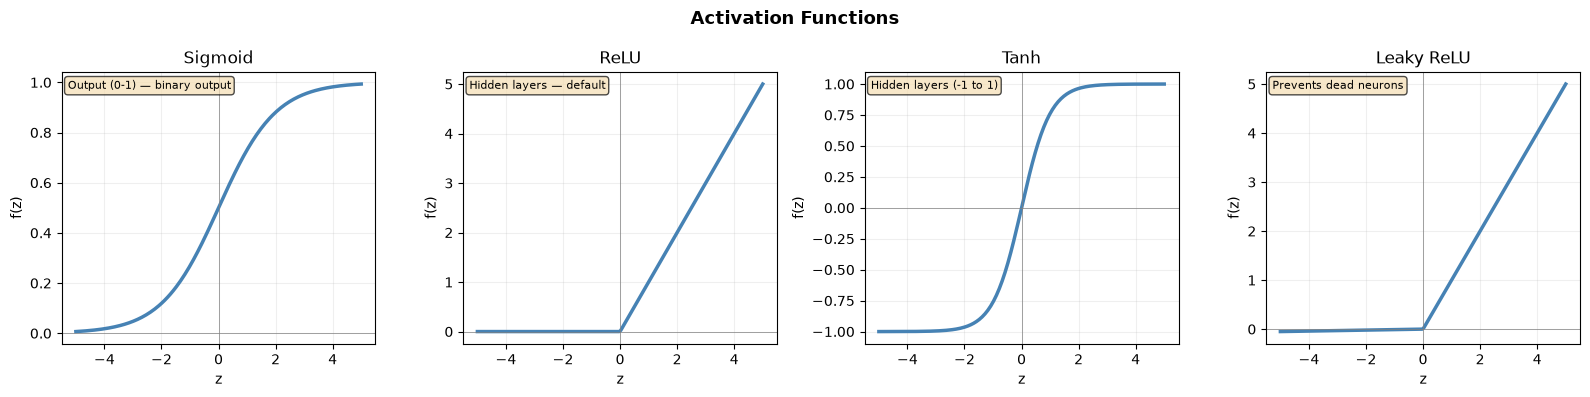

In [2]:
z = np.linspace(-5, 5, 200)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fns = [
    ('Sigmoid',    lambda z: 1/(1+np.exp(-z)), 'Output (0-1) — binary output'),
    ('ReLU',       lambda z: np.maximum(0, z),  'Hidden layers — default'),
    ('Tanh',       lambda z: np.tanh(z),         'Hidden layers (-1 to 1)'),
    ('Leaky ReLU', lambda z: np.where(z>0, z, 0.01*z), 'Prevents dead neurons'),
]
for ax, (name, fn, note) in zip(axes, fns):
    ax.plot(z, fn(z), linewidth=2.5, color='steelblue')
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.set_title(f'{name}')
    ax.set_xlabel('z'); ax.set_ylabel('f(z)')
    ax.grid(alpha=0.2)
    ax.text(0.02, 0.97, note, transform=ax.transAxes, fontsize=8, va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.suptitle('Activation Functions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/tmp/activation_fns.png', dpi=100)
plt.show()

## 3. Build a Neural Network from Scratch

XOR with Neural Network:
  [0 0] -> 0 (expected 0) OK
  [0 1] -> 1 (expected 1) OK
  [1 0] -> 1 (expected 1) OK
  [1 1] -> 0 (expected 0) OK


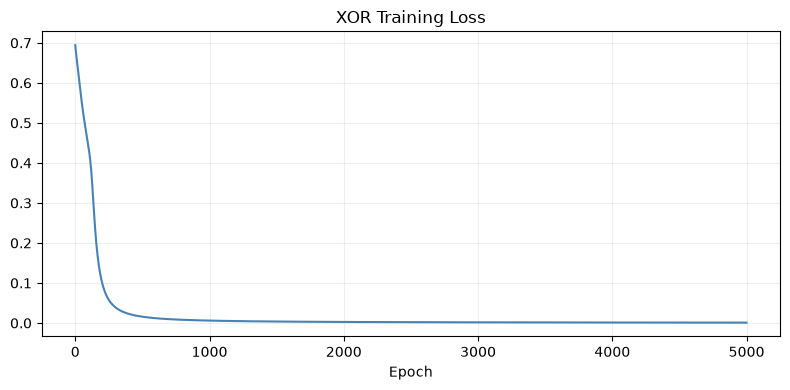

In [3]:
class SimpleNN:
    def __init__(self, n_in, n_hid, n_out, lr=0.01):
        self.lr = lr
        self.W1 = np.random.randn(n_hid, n_in) * np.sqrt(2/n_in)
        self.b1 = np.zeros((n_hid, 1))
        self.W2 = np.random.randn(n_out, n_hid) * np.sqrt(2/n_hid)
        self.b2 = np.zeros((n_out, 1))
    
    def sigmoid(self, z): return 1/(1+np.exp(-np.clip(z,-500,500)))
    
    def forward(self, X):
        self.z1 = self.W1 @ X + self.b1
        self.a1 = np.tanh(self.z1)
        self.z2 = self.W2 @ self.a1 + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2
    
    def backward(self, X, y):
        m = X.shape[1]
        dZ2 = self.a2 - y
        dW2 = dZ2 @ self.a1.T / m
        db2 = dZ2.mean(axis=1, keepdims=True)
        dZ1 = (self.W2.T @ dZ2) * (1 - self.a1**2)
        dW1 = dZ1 @ X.T / m
        db1 = dZ1.mean(axis=1, keepdims=True)
        self.W2 -= self.lr * dW2; self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1; self.b1 -= self.lr * db1
    
    def train(self, X, y, epochs=5000):
        losses = []
        for _ in range(epochs):
            yhat = self.forward(X)
            loss = -np.mean(y*np.log(yhat+1e-8)+(1-y)*np.log(1-yhat+1e-8))
            losses.append(loss)
            self.backward(X, y)
        return losses

# XOR — impossible for a single neuron, needs hidden layer
np.random.seed(42)
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]]).T
y_xor = np.array([[0,1,1,0]])

nn = SimpleNN(2, 4, 1, lr=0.5)
losses = nn.train(X_xor, y_xor, 5000)

print('XOR with Neural Network:')
for inp, target in zip(X_xor.T, y_xor[0]):
    pred = (nn.forward(inp.reshape(-1,1)) > 0.5).astype(int)[0][0]
    print(f'  {inp} -> {pred} (expected {target}) {"OK" if pred==target else "FAIL"}')

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(losses, color='steelblue')
ax.set_title('XOR Training Loss'); ax.set_xlabel('Epoch'); ax.grid(alpha=0.2)
plt.tight_layout(); plt.savefig('/tmp/xor_loss.png', dpi=100); plt.show()

## 4. sklearn MLPClassifier — Practical Neural Nets

In [4]:
bc = load_breast_cancer()
X_bc, y_bc = bc.data, bc.target
X_tr, X_te, y_tr, y_te = train_test_split(X_bc, y_bc, test_size=0.2, random_state=42)
sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr); X_te_s = sc.transform(X_te)

# Compare architectures
archs = [
    ('Shallow (16,)',       (16,)),
    ('Medium (64,32)',      (64, 32)),
    ('Deep (128,64,32)',    (128, 64, 32)),
    ('Wide (256,)',         (256,)),
]

results = {}
for name, layers in archs:
    mlp = MLPClassifier(hidden_layer_sizes=layers, max_iter=500,
                         random_state=42, early_stopping=True, validation_fraction=0.1)
    mlp.fit(X_tr_s, y_tr)
    results[name] = {
        'test': mlp.score(X_te_s, y_te),
        'train': mlp.score(X_tr_s, y_tr),
        'loss': mlp.loss_curve_
    }
    print(f'{name:<25}: Train={results[name]["train"]:.2%}, Test={results[name]["test"]:.2%}')

Shallow (16,)            : Train=89.89%, Test=92.11%
Medium (64,32)           : Train=96.04%, Test=97.37%


Deep (128,64,32)         : Train=98.02%, Test=96.49%
Wide (256,)              : Train=98.46%, Test=97.37%


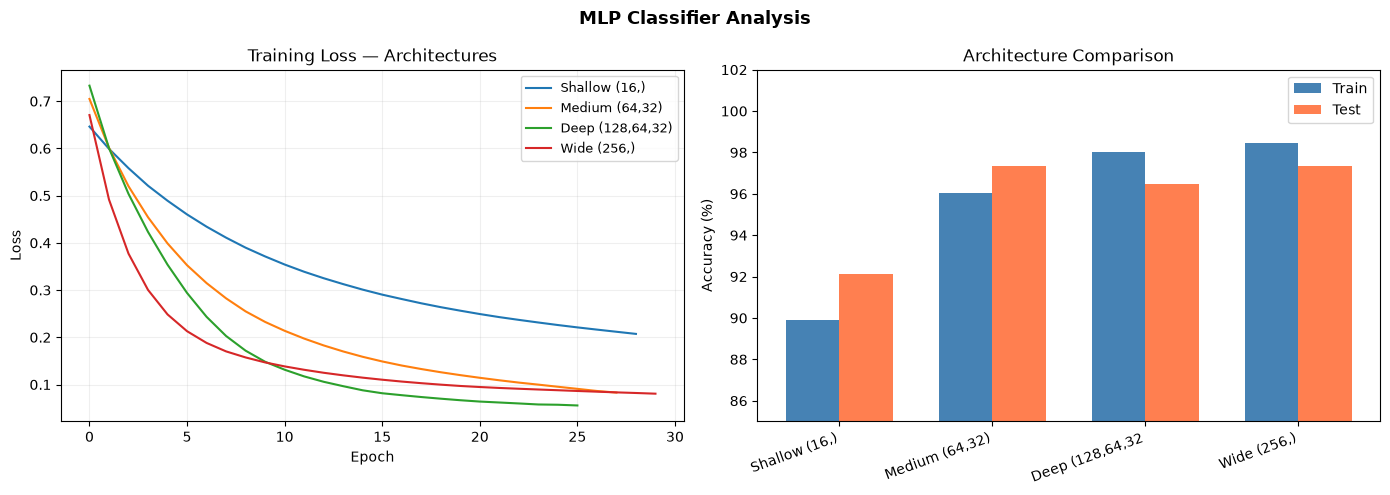

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, res in results.items():
    axes[0].plot(res['loss'], label=name, linewidth=1.5)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss — Architectures'); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.2)

names  = list(results.keys())
tr_acc = [results[n]['train']*100 for n in names]
te_acc = [results[n]['test']*100  for n in names]
xp = np.arange(len(names)); w = 0.35

axes[1].bar(xp-w/2, tr_acc, w, label='Train', color='steelblue')
axes[1].bar(xp+w/2, te_acc, w, label='Test',  color='coral')
axes[1].set_xticks(xp); axes[1].set_xticklabels([n[:15] for n in names], rotation=20, ha='right')
axes[1].set_ylabel('Accuracy (%)'); axes[1].set_title('Architecture Comparison')
axes[1].legend(); axes[1].set_ylim(85, 102)

plt.suptitle('MLP Classifier Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/tmp/mlp_analysis.png', dpi=100)
plt.show()

## 5. Early Stopping & Regularization

Without ES: 92 epochs, Test=97.37%
With ES:    33 epochs, Test=97.37%


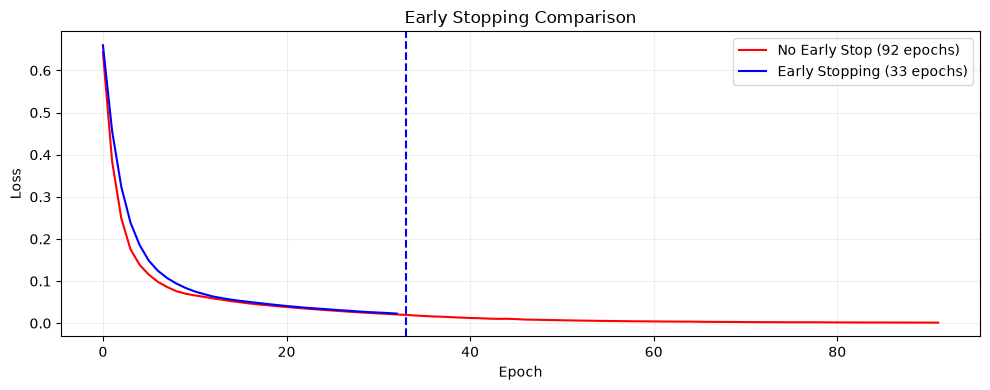

In [6]:
# Without early stopping: overfits
mlp_no_es = MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=500,
                           random_state=42, early_stopping=False)
mlp_no_es.fit(X_tr_s, y_tr)

# With early stopping: optimal
mlp_es = MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=500,
                        random_state=42, early_stopping=True,
                        validation_fraction=0.15, n_iter_no_change=20)
mlp_es.fit(X_tr_s, y_tr)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mlp_no_es.loss_curve_, 'r-', lw=1.5, label=f'No Early Stop ({len(mlp_no_es.loss_curve_)} epochs)')
ax.plot(mlp_es.loss_curve_,    'b-', lw=1.5, label=f'Early Stopping ({len(mlp_es.loss_curve_)} epochs)')
ax.axvline(len(mlp_es.loss_curve_), color='blue', linestyle='--', lw=1.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Early Stopping Comparison')
ax.legend(); ax.grid(alpha=0.2)

print(f'Without ES: {len(mlp_no_es.loss_curve_)} epochs, Test={mlp_no_es.score(X_te_s,y_te):.2%}')
print(f'With ES:    {len(mlp_es.loss_curve_)} epochs, Test={mlp_es.score(X_te_s,y_te):.2%}')

plt.tight_layout(); plt.savefig('/tmp/early_stopping.png', dpi=100); plt.show()

## 6. Keras/TensorFlow Example (install: `pip install tensorflow`)

In [7]:
try:
    import tensorflow as tf
    from tensorflow.keras import layers, Sequential
    
    model = Sequential([
        layers.Dense(128, activation='relu', input_shape=(X_bc.shape[1],)),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    model.summary()
    
    history = model.fit(X_tr_s, y_tr, epochs=100, batch_size=32,
                         validation_split=0.2, verbose=0)
    _, test_acc = model.evaluate(X_te_s, y_te, verbose=0)
    print(f'Keras model test accuracy: {test_acc:.2%}')

except ImportError:
    print('TensorFlow not installed. Showing equivalent sklearn code:')
    print()
    print('from sklearn.neural_network import MLPClassifier')
    print('model = MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=500)')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

Keras model test accuracy: 96.49%


## Summary

| Concept | Key Point |
|---|---|
| Architecture | Start: 2-3 hidden layers, 64-128 units |
| Activation | ReLU for hidden, Sigmoid/Softmax for output |
| Regularization | Dropout(0.2-0.5) + Early Stopping |
| Optimizer | Adam (default), SGD with momentum |
| When to use | Large data (>10k), images, text, audio |

**Next notebook →** `16_Time_Series_Analysis.ipynb`